<a href="https://colab.research.google.com/github/SarahSAH02/Dat255_prosjekt/blob/main/threshold_per_label_resnet_modell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (4).zip"
extract_path = "/content/chexpert"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Ferdig pakket ut!")

Ferdig pakket ut!


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Once your Google Drive is mounted, you can use the `ls` command to list the contents of directories. For example, to list the contents of your `MyDrive` folder, you would use `!ls /content/drive/MyDrive`. You can navigate through the folders to find your `archive (4).zip` file. Replace `your_path_here` with the path where you suspect the file is located.

In [17]:
# Example: List contents of MyDrive
# You might need to adjust this path based on where you think the file is.
!ls -R '/content/drive/MyDrive'

/content/drive/MyDrive:
'archive (4).zip'   best_model_resnet.pth  'Colab Notebooks'

'/content/drive/MyDrive/Colab Notebooks':
CNN_modell_ferdig.ipynb  Untitled0.ipynb


In [19]:
from google.colab import files
files.download("best_model_resnet.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# This will open a file selection dialog. Please select 'best_model_resnet.pth' from your local disk.
files.upload()

Saving best_model_resnet.pth to best_model_resnet.pth


In [20]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

In [31]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_img_path = os.path.join(extract_path, row['Path'])
        img = Image.open(full_img_path).convert("RGB")
        labels = row[1:].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(labels)

In [22]:
valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [26]:
import pandas as pd
import os

label_values = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]



valid_df = pd.read_csv(os.path.join(extract_path, "valid.csv"))



valid_df['Path'] = valid_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)


valid_df[label_values] = valid_df[label_values].fillna(0).replace(-1, 0)


valid_df = valid_df[['Path'] + label_values]



In [27]:
valid_dataset = CheXpertDataset(valid_df, valid_transform)

valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [28]:
def get_resnet():
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 14)
    return model

In [29]:
model = get_resnet()
model.load_state_dict(torch.load("best_model_resnet.pth", map_location="cpu"))
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [32]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

In [35]:
thresholds = np.linspace(0.1, 0.9, 17)
f1_scores = []

for t in thresholds:
    preds = (all_probs > t).astype(int)
    f1 = f1_score(all_labels, preds, average='macro')
    f1_scores.append(f1)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/di

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metr

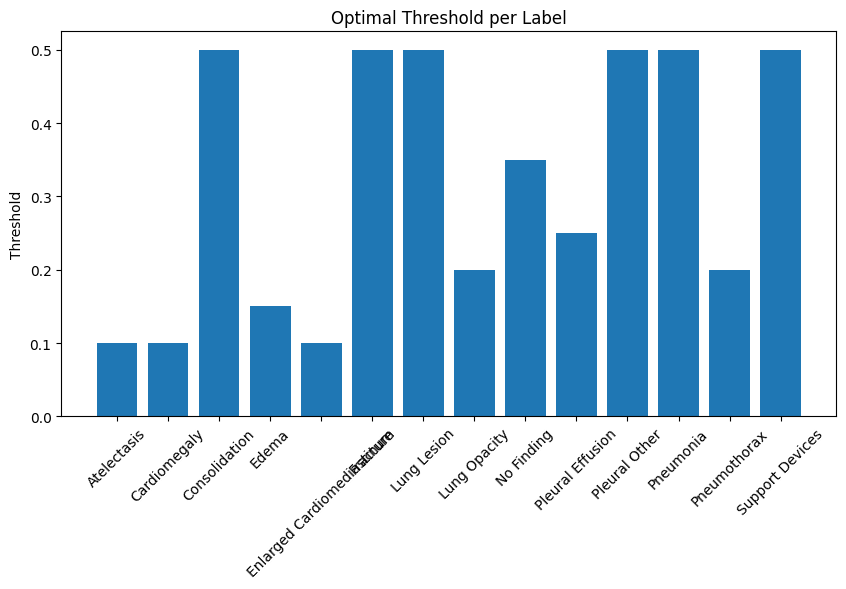

In [38]:
thresholds = []

for i in range(all_probs.shape[1]):  # 14 labels
    best_t = 0.5
    best_f1 = 0

    for t in np.linspace(0.1, 0.9, 17):
        preds = (all_probs[:, i] > t).astype(int)
        f1 = f1_score(all_labels[:, i], preds)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)

# Plot
plt.figure(figsize=(10,5))
plt.bar(label_values, thresholds)
plt.xticks(rotation=45)
plt.title("Optimal Threshold per Label")
plt.ylabel("Threshold")
plt.show()